# Reliability sorting · from four pixels to a spanning tree

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from parvaneh import (reliability_unwrap, pixel_reliability,
                      network_flow_unwrap, phase_residues, rmse_aligned)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, ORANGE, RED = '#2463a6', '#d78b26', '#b83d52'
def wrap(a):
    return (np.asarray(a) + np.pi) % (2*np.pi) - np.pi
def gradients(a):
    return wrap(np.diff(a, axis=1)), wrap(np.diff(a, axis=0))
def curl(gx, gy):
    return gx[:-1] + gy[:, 1:] - gx[1:] - gy[:, :-1]
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' +
        '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(map(str, row)) + ' |' for row in rows)))

## 1 · Four angles, two incompatible paths

Label the corners $A,B,C,D$ clockwise. Their measured phases, **in units of
$\pi$**, are $0,0.6,-0.8,-0.2$. These are actual pixel measurements;
we do not invent independent edge errors.

For a directed edge $a\to b$, compute

$$g_{ab}=W(w_b-w_a),\qquad W(t)=((t+\pi)\bmod 2\pi)-\pi.$$

Walk clockwise. The four steps are $0.6\pi,0.6\pi,0.6\pi,0.2\pi$.
Their sum is $2\pi$, giving residue $r=1$. In particular, from $A$ to $C$:

$$A\to B\to C: 1.2\pi,\qquad A\to D\to C:-0.8\pi.$$

Both paths look locally plausible, but their answers differ by one whole turn.
An ordinary scalar surface cannot have both sets of differences simultaneously.

| Clockwise edge | Raw difference / π | Wrapped step / π |
|---|---|---|
| A → B | 0.6 | 0.6 |
| B → C | -1.4 | 0.6 |
| C → D | 0.6 | 0.6 |
| D → A | 0.2 | 0.2 |

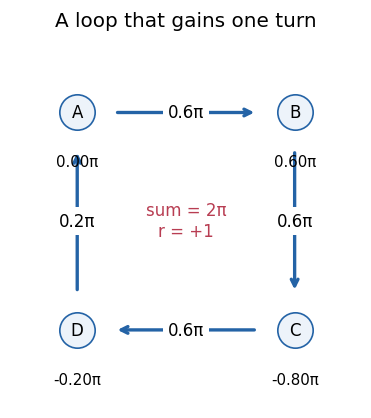

In [2]:
w = np.pi * np.array([[0.0, 0.6], [-0.2, -0.8]])
gx, gy = gradients(w)
steps = np.array([gx[0,0], gy[0,1], -gx[1,0], -gy[0,0]])
assert np.allclose(steps / np.pi, [.6, .6, .6, .2])
assert phase_residues(w)[0,0] == 1
table(['Clockwise edge', 'Raw difference / π', 'Wrapped step / π'],
      [(name, f'{raw:.1f}', f'{step:.1f}') for name, raw, step in
       zip(['A → B','B → C','C → D','D → A'], [.6,-1.4,.6,.2], steps/np.pi)])

xy = np.array([[0,1], [1,1], [0,0], [1,0]])  # flattened array order A,B,D,C
names = ['A','B','D','C']
def square(ax, values, title, edges=None, labels=None):
    edges = [(0,1),(1,3),(3,2),(2,0)] if edges is None else edges
    for i,(a,b) in enumerate(edges):
        p,q = xy[a],xy[b]
        ax.annotate('', xy=q*.83+p*.17, xytext=p*.83+q*.17,
                    arrowprops=dict(arrowstyle='->', color=BLUE, lw=2))
        if labels is not None:
            mid=(p+q)/2
            ax.text(*mid, labels[i], ha='center', va='center',
                    bbox=dict(facecolor='white', edgecolor='none', pad=3))
    for i,p in enumerate(xy):
        ax.scatter(*p, s=450, color='#edf3fa', edgecolor=BLUE, zorder=3)
        ax.text(p[0],p[1],names[i],ha='center',va='center',zorder=4)
        ax.text(p[0],p[1]-.25,f'{values.ravel()[i]/np.pi:.2f}π',ha='center',fontsize=9)
    ax.set(xlim=(-.3,1.3),ylim=(-.35,1.35),aspect='equal',title=title)
    ax.axis('off')
fig,ax=plt.subplots(figsize=(5,4))
square(ax,w,'A loop that gains one turn',labels=['0.6π','0.6π','0.6π','0.2π'])
ax.text(.5,.5,'sum = 2π\nr = +1',ha='center',va='center',color=RED)
plt.show()

## 2 · Reliability: which edge should we trust first?

Parvaneh uses an axial-neighbor score. With unit confidence,

$$S_p=\sum_{q\in N(p)}|W(w_q-w_p)|,\qquad R_p=\frac{1}{1+S_p}.$$

For $A$, $S_A=0.6\pi+0.2\pi=0.8\pi$, so $R_A\approx0.285$.
For $B$, $S_B=1.2\pi$, so $R_B\approx0.210$. Rate an edge using its
less reliable endpoint: $P_{ab}=\min(R_a,R_b)$.

This score is a heuristic, not a probability of correctness. A steep but correct
fringe may receive a low score. With supplied pixel confidence $c$, each term
in $S_p$ is multiplied by $\min(c_p,c_q)$; this is the implementation's specific
rating, not a claim that all published reliability algorithms use this formula.

In [3]:
rating=pixel_reliability(w)
table(['Pixel','Neighbor-step sum','Reliability'],
      [(names[i],f'{(1/r-1)/np.pi:.2f}π',f'{r:.4f}')
       for i,r in enumerate(rating.ravel())])
assert np.isclose(rating[0,0],1/(1+.8*np.pi))

| Pixel | Neighbor-step sum | Reliability |
|---|---|---|
| A | 0.80π | 0.2846 |
| B | 1.20π | 0.2096 |
| D | 0.80π | 0.2846 |
| C | 1.20π | 0.2096 |

## 3 · Grow the tree, then integrate

Start with four separate components. Sort the edges by decreasing priority.
Accept an edge only if its endpoints belong to different components; otherwise
it would close a loop. Stop merging once the image is connected.

For each accepted edge impose $u_b-u_a=g_{ab}$. Equivalently, writing
$u_p=w_p+2\pi n_p$ gives

$$n_b-n_a=\frac{g_{ab}-(w_b-w_a)}{2\pi},$$

an integer. Joining two existing components shifts one component by whole turns
so their connecting edge agrees. Parvaneh stores these shifts in a union–find
structure; below we use a short tree traversal so the arithmetic stays visible.
The edge enumeration and stable tie ordering follow the Python implementation.

| Visit | Edge | Priority | Decision |
|---|---|---|---|
| 1 | A–D | 0.2846 | merge |
| 2 | B–C | 0.2096 | merge |
| 3 | A–B | 0.2096 | merge |
| 4 | D–C | 0.2096 | skip: closes a loop |

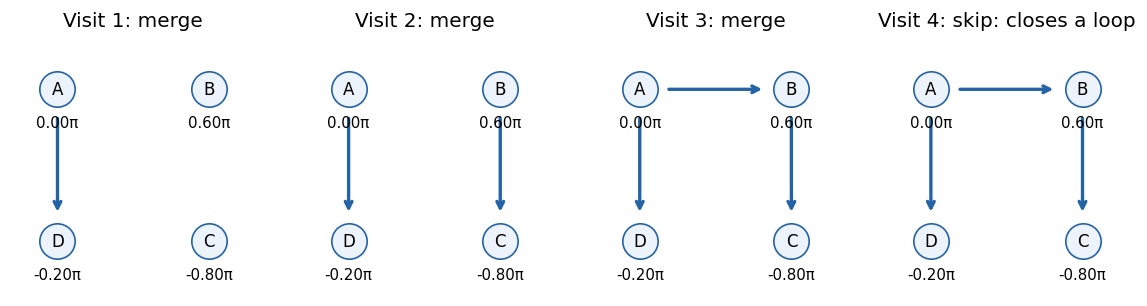

| Pixel | Measured / π | Tree result / π | Integer turns added |
|---|---|---|---|
| A | 0.0 | 0.0 | 0 |
| B | 0.6 | 0.6 | 0 |
| D | -0.2 | -0.2 | 0 |
| C | -0.8 | 1.2 | 1 |

In [4]:
# Axis 0 edges first, then axis 1 edges, exactly as in reliability_unwrap.
edges=[(0,2),(1,3),(0,1),(2,3)]
priority=np.array([min(rating.ravel()[a],rating.ravel()[b]) for a,b in edges])
order=np.argsort(-priority,kind='stable')
parent=list(range(4))
def root(a):
    while parent[a]!=a: a=parent[a]
    return a
accepted=[]; trace=[]; snapshots=[]
for rank,e in enumerate(order,1):
    a,b=edges[e]; ra,rb=root(a),root(b)
    take=ra!=rb
    if take:
        parent[rb]=ra; accepted.append((a,b))
    trace.append([rank,names[a]+'–'+names[b],f'{priority[e]:.4f}',
                  'merge' if take else 'skip: closes a loop'])
    snapshots.append(accepted.copy())
table(['Visit','Edge','Priority','Decision'],trace)
fig,axes=plt.subplots(1,4,figsize=(12,3))
for ax,tree,row in zip(axes,snapshots,trace):
    square(ax,w,f'Visit {row[0]}: {row[3]}',edges=tree)
plt.show()

u=np.full(4,np.nan); u[0]=w.ravel()[0]
queue=[0]
while queue:
    a=queue.pop(0)
    for i,j in accepted:
        b=j if i==a else i if j==a else None
        if b is not None and np.isnan(u[b]):
            u[b]=u[a]+wrap(w.ravel()[b]-w.ravel()[a]); queue.append(b)
tree_result=u.reshape(w.shape)
library_tree, tree_info=reliability_unwrap(w,return_info=True)
assert np.allclose(tree_result-tree_result[0,0],library_tree-library_tree[0,0])
assert tree_info.merges == tree_info.pixels-tree_info.components == 3
table(['Pixel','Measured / π','Tree result / π','Integer turns added'],
      [(names[i],f'{w.ravel()[i]/np.pi:.1f}',f'{u[i]/np.pi:.1f}',
        int(round((u[i]-w.ravel()[i])/(2*np.pi)))) for i in range(4)])

### What did skipping an edge achieve?

A tree has exactly one path between each pair of pixels, so it can always be
integrated. It does **not** satisfy every original edge: here the omitted edge
carries the loop disagreement. On residue-free data an omitted edge can agree
perfectly. `discarded` counts loop-closing edges, not detected errors.

The algorithm maximizes the sum of the chosen edge priorities (a maximum
spanning tree). It does not minimize reconstruction error against unknown truth,
nor does it minimize the flow objective introduced next.